<a href="https://colab.research.google.com/github/Ishy49/MLT/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import pandas as pd


In [9]:

df = pd.read_csv("etrain_delays.csv")
df.head()


,train_number,train_name,station_code,station_name,average_delay_minutes,pct_right_time,pct_slight_delay,pct_significant_delay,pct_cancelled_unknown,scraped_at,source_url
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27T12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27T12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27T12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...
4,12673,Cheran Express,JTJ,JOLARPETTAI,NaN,70.96,27.67,1.37,0.00,2025-09-27T12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...


In [10]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   train_number           1900 non-null   int64  
 1   train_name             1900 non-null   object 
 2   station_code           1900 non-null   object 
 3   station_name           1900 non-null   object 
 4   average_delay_minutes  1664 non-null   float64
 5   pct_right_time         1900 non-null   float64
 6   pct_slight_delay       1900 non-null   float64
 7   pct_significant_delay  1900 non-null   float64
 8   pct_cancelled_unknown  1900 non-null   float64
 9   scraped_at             1900 non-null   object 
 10  source_url             1900 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 163.4+ KB


(1900, 11)

In [11]:
df.columns = ['train_number','train_name','station_code','station_name',
              'avg_delay_min','pct_right_time','pct_slight_delay',
              'pct_significant_delay','total_records','scraped_at','extra']

df.head()


,train_number,train_name,station_code,station_name,avg_delay_min,pct_right_time,pct_slight_delay,pct_significant_delay,total_records,scraped_at,extra
0,12673,Cheran Express,MAS,CHENNAI CENTRAL,2.0,98.90,0.27,0.00,0.83,2025-09-27T12:25:37.767628+00:00,https://etrain.info/train/Cheran-Express-12673...
1,12673,Cheran Express,AVD,AVADI,0.0,0.27,0.00,0.00,99.73,2025-09-27T12:25:39.293769+00:00,https://etrain.info/train/Cheran-Express-12673...
2,12673,Cheran Express,AJJ,ARAKKONAM,16.0,55.34,44.38,0.27,0.01,2025-09-27T12:25:40.672610+00:00,https://etrain.info/train/Cheran-Express-12673...
3,12673,Cheran Express,KPD,KATPADI JN,17.0,48.49,49.86,1.64,0.01,2025-09-27T12:25:42.125216+00:00,https://etrain.info/train/Cheran-Express-12673...
4,12673,Cheran Express,JTJ,JOLARPETTAI,NaN,70.96,27.67,1.37,0.00,2025-09-27T12:25:44.585700+00:00,https://etrain.info/train/Cheran-Express-12673...


In [12]:
df.isnull().sum()


,0
train_number,0
train_name,0
station_code,0
station_name,0
avg_delay_min,236
pct_right_time,0
pct_slight_delay,0
pct_significant_delay,0
total_records,0
scraped_at,0


In [13]:
df = df.dropna(subset=['avg_delay_min'])


In [14]:
df['scraped_at'] = pd.to_datetime(df['scraped_at'], errors='coerce')

df['day_of_week'] = df['scraped_at'].dt.dayofweek
df['month'] = df['scraped_at'].dt.month


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['train_number'] = le.fit_transform(df['train_number'])
df['station_code'] = le.fit_transform(df['station_code'])
df['station_name'] = le.fit_transform(df['station_name'])


In [16]:
df['pct_right_time'] = pd.to_numeric(df['pct_right_time'], errors='coerce')
df['pct_slight_delay'] = pd.to_numeric(df['pct_slight_delay'], errors='coerce')
df['pct_significant_delay'] = pd.to_numeric(df['pct_significant_delay'], errors='coerce')


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['avg_delay_min','pct_right_time',
    'pct_slight_delay','pct_significant_delay']] = scaler.fit_transform(
    df[['avg_delay_min','pct_right_time',
        'pct_slight_delay','pct_significant_delay']]
)


In [18]:
df = df.drop(['train_name','scraped_at','extra'], axis=1, errors='ignore')


In [19]:
df.to_csv("cleaned_etrain_delays.csv", index=False)


In [20]:
print(df.columns.tolist())


['train_number', 'station_code', 'station_name', 'avg_delay_min', 'pct_right_time', 'pct_slight_delay', 'pct_significant_delay', 'total_records', 'day_of_week', 'month']


In [21]:
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Summer"
    elif month in [6,7,8,9]:
        return "Monsoon"
    else:
        return "PostMonsoon"

df['season'] = df['month'].apply(get_season)

df[['month','season']].head()


,month,season
0,9,Monsoon
1,9,Monsoon
2,9,Monsoon
3,9,Monsoon
5,9,Monsoon


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['season'] = le.fit_transform(df['season'])


In [23]:
df.to_csv("etrain_delays_with_season.csv", index=False)


EDA


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
df = pd.read_csv("etrain_delays_with_season.csv")

print("Dataset Preview:\n")
print(df.head())

Dataset Preview:

   train_number  station_code  station_name  avg_delay_min  pct_right_time  \
0            50           266            95      -0.769025        1.500050   
1            50            28            31      -0.808769       -1.511852   
2            50            12            26      -0.490821        0.169842   
3            50           228           215      -0.470950       -0.039339   
4            50           384           389      -0.311976       -0.817432   

   pct_slight_delay  pct_significant_delay  total_records  day_of_week  month  \
0         -1.296616              -0.701523           0.83            5      9   
1         -1.307207              -0.701523          99.73            5      9   
2          0.433697              -0.689482           0.01            5      9   
3          0.648663              -0.628387           0.01            5      9   
4          1.626598              -0.603859           0.01            5      9   

   season  
0       0  
1 

In [26]:
print("\nDataset Info:\n")
print(df.info())

print("\nDataset Shape:", df.shape)


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1664 entries, 0 to 1663
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   train_number           1664 non-null   int64  
 1   station_code           1664 non-null   int64  
 2   station_name           1664 non-null   int64  
 3   avg_delay_min          1664 non-null   float64
 4   pct_right_time         1664 non-null   float64
 5   pct_slight_delay       1664 non-null   float64
 6   pct_significant_delay  1664 non-null   float64
 7   total_records          1664 non-null   float64
 8   day_of_week            1664 non-null   int64  
 9   month                  1664 non-null   int64  
 10  season                 1664 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 143.1 KB
None

Dataset Shape: (1664, 11)


In [27]:
print("\nDescriptive Statistics:\n")
print(df.describe())


Descriptive Statistics:

       train_number  station_code  station_name  avg_delay_min  \
count   1664.000000   1664.000000   1664.000000   1.664000e+03   
mean      46.727163    238.519832    241.783654  -2.135044e-17   
std       25.120421    138.817507    140.254648   1.000301e+00   
min        0.000000      0.000000      0.000000  -8.087685e-01   
25%       26.000000    117.000000    117.750000  -5.504365e-01   
50%       50.000000    241.500000    237.500000  -3.318478e-01   
75%       70.000000    359.000000    363.000000   1.649446e-01   
max       89.000000    475.000000    475.000000   1.083605e+01   

       pct_right_time  pct_slight_delay  pct_significant_delay  total_records  \
count    1.664000e+03      1.664000e+03           1.664000e+03    1664.000000   
mean     1.537232e-16      6.191628e-17           9.394195e-17       1.167482   
std      1.000301e+00      1.000301e+00           1.000301e+00       9.356167   
min     -1.520097e+00     -1.307207e+00          -7.015

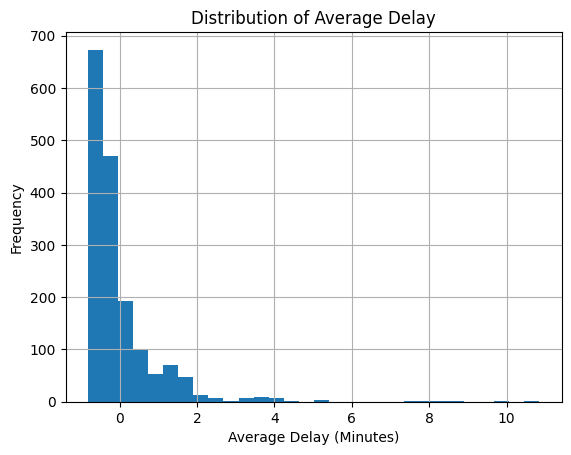

In [ ]:
df['avg_delay_min'].hist(bins=30)
plt.title("Distribution of Average Delay")
plt.xlabel("Average Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

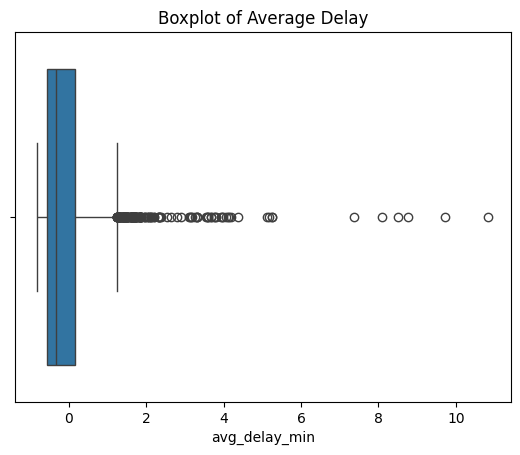

In [ ]:
sns.boxplot(x=df['avg_delay_min'])
plt.title("Boxplot of Average Delay")
plt.show()

In [ ]:
corr_matrix = df.corr()

print("\nCorrelation Matrix:\n")
print(corr_matrix)


Correlation Matrix:

                       train_number  station_code  station_name  \
train_number               1.000000      0.049039      0.016899   
station_code               0.049039      1.000000      0.870445   
station_name               0.016899      0.870445      1.000000   
avg_delay_min             -0.060077     -0.066846     -0.054281   
pct_right_time             0.076412      0.064614      0.032870   
pct_slight_delay          -0.097404     -0.001345      0.021170   
pct_significant_delay     -0.011323     -0.072119     -0.051860   
total_records              0.025097     -0.049649     -0.048442   
day_of_week                     NaN           NaN           NaN   
month                           NaN           NaN           NaN   
season                          NaN           NaN           NaN   

                       avg_delay_min  pct_right_time  pct_slight_delay  \
train_number               -0.060077        0.076412         -0.097404   
station_code             

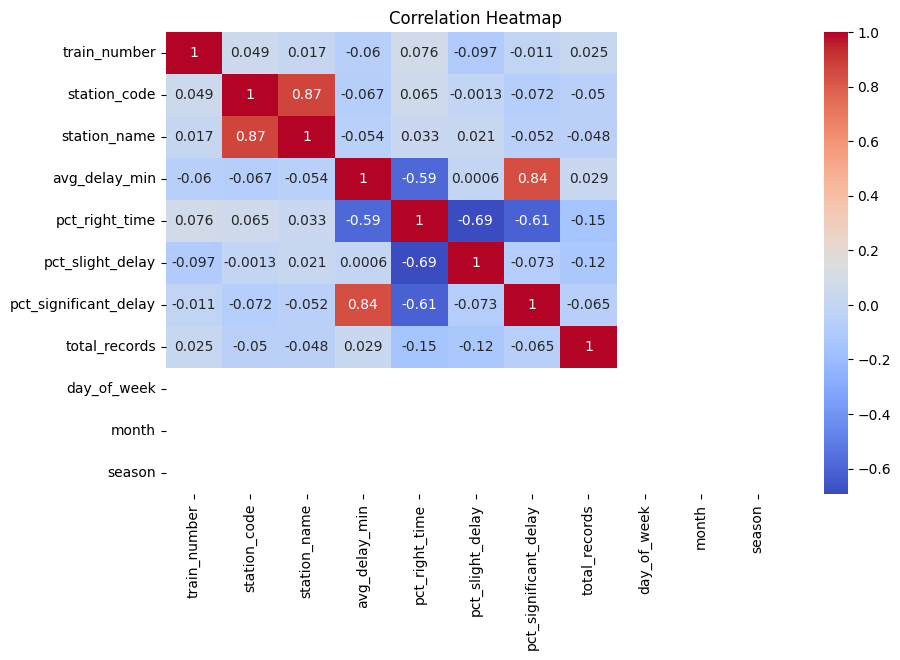

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Practical 3

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data
df = pd.read_csv("etrain_delays_with_season.csv")

# Convert to binary (0 = low delay, 1 = high delay)
df['delay_binary'] = (df['avg_delay_min'] > 5).astype(int)

# Convert categorical to numeric
df = pd.get_dummies(df)

# Features and target
X = df.drop(['avg_delay_min', 'delay_binary'], axis=1)
y = df['delay_binary']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.993993993993994
Confusion Matrix:
 [[331   1]
 [  1   0]]


KNN


In [45]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
print(df.head())
print(df.columns)


   train_number  station_code  station_name  avg_delay_min  pct_right_time  \
0            50           266            95      -0.769025        1.500050   
1            50            28            31      -0.808769       -1.511852   
2            50            12            26      -0.490821        0.169842   
3            50           228           215      -0.470950       -0.039339   
4            50           384           389      -0.311976       -0.817432   

   pct_slight_delay  pct_significant_delay  total_records  day_of_week  month  \
0         -1.296616              -0.701523           0.83            5      9   
1         -1.307207              -0.701523          99.73            5      9   
2          0.433697              -0.689482           0.01            5      9   
3          0.648663              -0.628387           0.01            5      9   
4          1.626598              -0.603859           0.01            5      9   

   season  
0       0  
1       0  
2       

In [31]:
X = df.drop('avg_delay_min', axis=1)
y = df['avg_delay_min']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [44]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 0.20867072887267235
MSE: 0.2900297402522846
R2 Score: 0.7659171887591714


In [42]:
for k in range(1, 11):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    print(f"K={k}, MAE={mae:.4f}")

K=1, MAE=0.1972
K=2, MAE=0.1911
K=3, MAE=0.1961
K=4, MAE=0.1965
K=5, MAE=0.2087
K=6, MAE=0.2051
K=7, MAE=0.2138
K=8, MAE=0.2116
K=9, MAE=0.2103
K=10, MAE=0.2104


practical 5

In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [50]:
df = pd.read_csv("etrain_delays_with_season.csv")

In [53]:
X = df.drop('avg_delay_min', axis=1)
y = df['avg_delay_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Performance:
MAE: 0.24264735448579935
MSE: 0.34667596764479897
RMSE: 0.5887919561651628
R2 Score: 0.720198056153347


In [55]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)


mae = mean_absolute_error(y_test, y_pred_poly)
mse = mean_squared_error(y_test, y_pred_poly)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_poly)

print("\nPolynomial Regression Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Polynomial Regression Performance:
MAE: 0.2516094848419379
MSE: 0.277574657940389
RMSE: 0.5268535450581964
R2 Score: 0.7759696774428089


practical 6


In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
df = pd.read_csv("etrain_delays_with_season.csv")

X = df.drop('avg_delay_min', axis=1)
y = df['avg_delay_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2 Score:", r2_score(y_test, y_pred_ridge))

Ridge Regression:
MAE: 0.24241242664232132
MSE: 0.346653658220636
RMSE: 0.5887730107780382
R2 Score: 0.720216062074811


In [60]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression:
MAE: 0.24085943805852522
MSE: 0.37167812945702106
RMSE: 0.6096541064054445
R2 Score: 0.7000188279162285


In [61]:
print("\nModel Comparison:")
print("Ridge R2:", r2_score(y_test, y_pred_ridge))
print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Model Comparison:
Ridge R2: 0.720216062074811
Lasso R2: 0.7000188279162285


practical 7


In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [64]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [65]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=5, scoring='r2')

    print(f"{name} Cross-Validation R2 Scores:", scores)
    print(f"{name} Average R2:", scores.mean())
    print("-" * 50)

Linear Regression Cross-Validation R2 Scores: [0.57844157 0.80232339 0.87671182 0.69084666 0.67285845]
Linear Regression Average R2: 0.7242363769335703
--------------------------------------------------
Ridge Cross-Validation R2 Scores: [0.57982048 0.80280464 0.87691376 0.69127445 0.67287225]
Ridge Average R2: 0.7247371186164149
--------------------------------------------------
Lasso Cross-Validation R2 Scores: [0.5642132  0.8084031  0.89216646 0.66293181 0.68810962]
Lasso Average R2: 0.7231648368920401
--------------------------------------------------
KNN Cross-Validation R2 Scores: [0.64082075 0.87553602 0.90983281 0.80925977 0.69734913]
KNN Average R2: 0.7865596989006887
--------------------------------------------------


In [66]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Performance:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))


Linear Regression Performance:
MAE: 0.24264735448580027
MSE: 0.3466759676447998
RMSE: 0.5887919561651634
R2 Score: 0.7201980561533463

Ridge Performance:
MAE: 0.24241242664232135
MSE: 0.34665365822063604
RMSE: 0.5887730107780383
R2 Score: 0.720216062074811

Lasso Performance:
MAE: 0.24085943805852528
MSE: 0.37167812945702106
RMSE: 0.6096541064054445
R2 Score: 0.7000188279162285

KNN Performance:
MAE: 0.20867072887267235
MSE: 0.2900297402522846
RMSE: 0.5385440931365645
R2 Score: 0.7659171887591714


practical 8


In [67]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.8427898472453255
Test Score: 0.7659171887591714


In [94]:
# Define model complexity
degrees = [1, 2, 3, 4, 5]

train_errors = []
test_errors = []

for d in degrees:
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Store errors
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

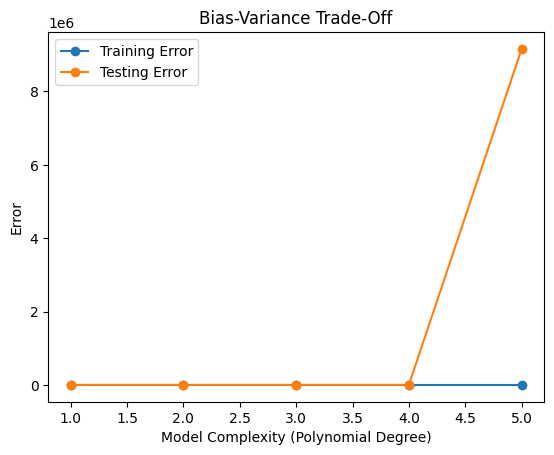

In [95]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(degrees, train_errors, marker='o', label='Training Error')
plt.plot(degrees, test_errors, marker='o', label='Testing Error')

plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Error")
plt.title("Bias-Variance Trade-Off")

plt.legend()
plt.show()

practical 9

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [81]:
df['delay_binary'] = (df['avg_delay_min'] > 15).astype(int)

X = df.drop(['avg_delay_min', 'delay_binary'], axis=1).values
y = df['delay_binary'].values

weights = np.zeros(X_train.shape[1])
bias = 0
learning_rate = 0.01
epochs = 20

for epoch in range(epochs):
    for i in range(len(X_train)):
        z = np.dot(X_train[i], weights) + bias
        y_pred = 1 if z >= 0 else 0

        error = y_train[i] - y_pred

        weights = weights + learning_rate * error * X_train[i]
        bias = bias + learning_rate * error

In [82]:
def predict(X):
    z = np.dot(X, weights) + bias
    return np.array([1 if val >= 0 else 0 for val in z])

y_pred = predict(X_test)

In [83]:
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


practical 10


In [84]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:
df = pd.get_dummies(df)

X = df.drop('avg_delay_min', axis=1)
y = df['avg_delay_min']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 2 hidden layers
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

In [87]:
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

In [88]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MLP Performance:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MLP Performance:
MAE: 0.16877320589980507
MSE: 0.1401132416615898
RMSE: 0.3743170336246934
R2 Score: 0.8869146954664688
